In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("DATA/CleanedDiabetic_data.csv")

print("Shape:", df.shape)
df.head()


Shape: (101766, 45)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [2]:

X = df.drop(columns=["target"])
y = df["target"]

print("Features (X):", X.shape)
print("Target (y):", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

Features (X): (101766, 44)
Target (y): (101766,)

Target distribution:
target
0    90409
1    11357
Name: count, dtype: int64

Target percentage:
target
0    88.840084
1    11.159916
Name: proportion, dtype: float64


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train: (81412, 44)
X_test: (20354, 44)

y_train distribution:
target
0    88.839483
1    11.160517
Name: proportion, dtype: float64

y_test distribution:
target
0    88.842488
1    11.157512
Name: proportion, dtype: float64


In [4]:

print("Data types:")
print(X_train.dtypes)

print("\nCategorical columns detected by Pandas:")

categorical_columns = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print(categorical_columns)

print("\nNumerical columns detected by Pandas:")

numerical_columns = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print(numerical_columns)

Data types:
race                          str
gender                        str
age                           str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
metformin                     str
repaglinide                   str
nateglinide                   str
chlorpropamide                str
glimepiride                   str
acetohexamide                 str
glipizide                     str
glyburide                     str
tolbutamide                   str
pioglitazone                  str
ro

C:\Users\mshlo\AppData\Local\Temp\ipykernel_15504\575085914.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(


In [5]:
categorical_id_columns = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]
categorical_columns = categorical_columns + categorical_id_columns

numerical_columns = [
    col for col in numerical_columns
    if col not in categorical_id_columns
]

print("Number of numerical features:", len(numerical_columns))
print("Number of categorical features:", len(categorical_columns))

print("\nNUMERICAL:")
print(numerical_columns)

print("\nCATEGORICAL:")
print(categorical_columns)

Number of numerical features: 8
Number of categorical features: 36

NUMERICAL:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

CATEGORICAL:
['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

In [8]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal test shape:", X_test.shape)
print("Processed test shape:", X_test_processed.shape)

Original training shape: (81412, 44)
Processed training shape: (81412, 2322)

Original test shape: (20354, 44)
Processed test shape: (20354, 2322)


In [13]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    solver="liblinear"
)
logistic_model.fit(X_train_processed, y_train)
print("Logistic Regression training complete.")

y_pred = logistic_model.predict(X_test_processed)
y_prob = logistic_model.predict_proba(X_test_processed)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("PR-AUC   :", average_precision_score(y_test, y_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))





Logistic Regression training complete.
Accuracy : 0.661344207526776
Precision: 0.18027116768123963
Recall   : 0.5737560546014971
F1 Score : 0.27434466785977474
ROC-AUC  : 0.6705596457920084
PR-AUC   : 0.22065853975236394

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.67      0.78     18083
           1       0.18      0.57      0.27      2271

    accuracy                           0.66     20354
   macro avg       0.55      0.62      0.53     20354
weighted avg       0.84      0.66      0.72     20354


Confusion Matrix:
[[12158  5925]
 [  968  1303]]


In [14]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

import pandas as pd

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    predictions = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(y_test, predictions),
        "recall": recall_score(y_test, predictions),
        "f1": f1_score(y_test, predictions)
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.to_string(index=False))

best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("Best threshold by F1:")
print(best_row)

print("\nThresholds with recall >= 0.60:")
print(
    threshold_df[
        threshold_df["recall"] >= 0.60
    ].to_string(index=False)
)

 threshold  precision   recall       f1
      0.10   0.114270 0.996477 0.205028
      0.15   0.115629 0.991634 0.207109
      0.20   0.117250 0.979304 0.209426
      0.25   0.120554 0.962572 0.214272
      0.30   0.125781 0.922061 0.221365
      0.35   0.133812 0.860854 0.231621
      0.40   0.145327 0.777191 0.244867
      0.45   0.162026 0.681638 0.261818
      0.50   0.180271 0.573756 0.274345
      0.55   0.199620 0.463232 0.279008
      0.60   0.226410 0.367679 0.280248
      0.65   0.249898 0.270806 0.259932
      0.70   0.284898 0.197710 0.233429
      0.75   0.323810 0.134742 0.190299
      0.80   0.361111 0.085865 0.138741
      0.85   0.413793 0.052840 0.093713
      0.90   0.504425 0.025099 0.047819
Best threshold by F1:
threshold    0.600000
precision    0.226410
recall       0.367679
f1           0.280248
Name: 10, dtype: float64

Thresholds with recall >= 0.60:
 threshold  precision   recall       f1
      0.10   0.114270 0.996477 0.205028
      0.15   0.115629 0.991634 0

Matplotlib is building the font cache; this may take a moment.


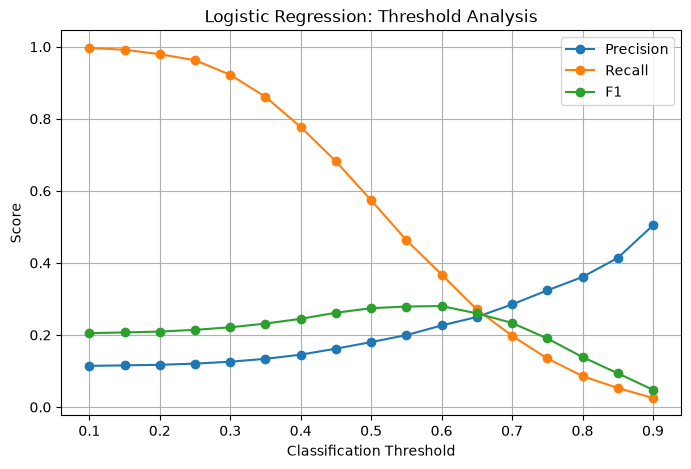

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Logistic Regression: Threshold Analysis")
plt.legend()
plt.grid(True)

plt.show()